# 🧠 Predição de AVC com Machine Learning

## 📌 Objetivo

Este projeto tem como objetivo desenvolver um modelo de Machine Learning para prever a ocorrência de AVC (Acidente Vascular Cerebral) a partir de dados clínicos e demográficos.

## 🎯 Abordagem

Serão realizadas etapas de análise exploratória, pré-processamento dos dados, tratamento de desbalanceamento (como SMOTE) e treinamento de diferentes modelos de classificação.

A avaliação será baseada principalmente em **Recall**, além de **F1-score** e **ROC AUC**, devido à natureza crítica do problema.


## EDA - Análise Exploratória dos Dados

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## 1. Carregando o dataset

Nesta etapa, carregamos o arquivo CSV em um DataFrame do pandas, que será a base para toda a análise e modelagem.

Ao visualizar as primeiras linhas (`head()`), buscamos identificar:
- estrutura das colunas
- tipos de variáveis (numéricas e categóricas)
- representação da variável alvo (`stroke`)

In [ ]:
print("Dimensão do dataset:", df.shape)
print("\nColunas:")
print(df.columns.tolist())

print("\nTipos de dados:")
print(df.dtypes)

Dimensão do dataset: (5110, 12)

Colunas:
['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']

Tipos de dados:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


## 2. Estrutura geral do dataset

Nesta etapa, analisamos a dimensão do dataset, os nomes das colunas e os tipos de dados.

Essa análise permite identificar:
- variáveis categóricas que serão transformadas via One-Hot Encoding
- variáveis numéricas que podem exigir padronização, dependendo do modelo
- a definição da variável alvo

In [ ]:
df.info()

print("\nValores nulos por coluna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Valores nulos por coluna:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_

## 3. Verificando dados faltantes

Identificamos valores nulos com `info()` e `isnull().sum()`.

Os dados ausentes, especialmente na variável `bmi`, serão tratados na etapa de pré-processamento, utilizando técnicas de imputação.

In [ ]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


## 4. Estatísticas das variáveis numéricas

Utilizamos `describe()` para obter um resumo estatístico das variáveis numéricas.

Essa análise auxilia na identificação de diferenças de escala, possíveis outliers e padrões de distribuição, que podem influenciar etapas como padronização e escolha de modelos.

In [ ]:
print("Distribuição da variável alvo (stroke):")
print(df['stroke'].value_counts())

print("\nDistribuição percentual:")
print(df['stroke'].value_counts(normalize=True) * 100)

Distribuição da variável alvo (stroke):
stroke
0    4861
1     249
Name: count, dtype: int64

Distribuição percentual:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


## 5. Verificando o desbalanceamento da variável alvo

A variável `stroke` representa o alvo do modelo (0 = não, 1 = sim).

Observa-se desbalanceamento entre as classes, com menor ocorrência de casos positivos.

Esse comportamento orienta a escolha de métricas como **Recall**, **F1-score** e **ROC AUC**, além do uso de técnicas de balanceamento como SMOTE.

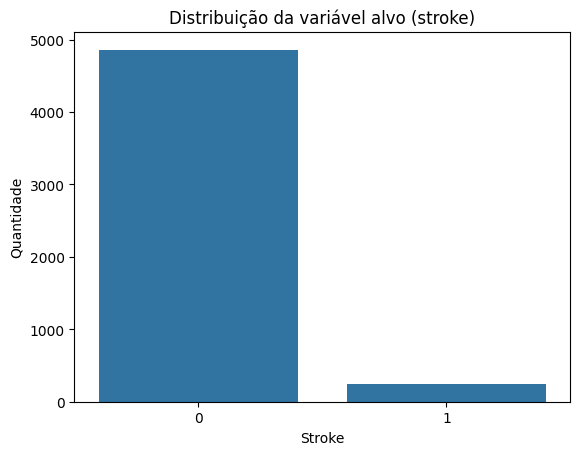

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='stroke')
plt.title('Distribuição da variável alvo (stroke)')
plt.xlabel('Stroke')
plt.ylabel('Quantidade')
plt.show()

## 6. Visualizando o alvo graficamente

O gráfico evidencia o desbalanceamento entre as classes, com menor ocorrência de `stroke = 1`.

Esse padrão reforça a necessidade de ajustar a estratégia de modelagem, incluindo o uso de métricas adequadas e técnicas como `class_weight` ou SMOTE.

In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Colunas categóricas:", cat_cols)
print("Colunas numéricas:", num_cols)

Colunas categóricas: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
Colunas numéricas: ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']


## 7. Identificando tipos de variáveis

As variáveis foram separadas em numéricas e categóricas para permitir tratamentos adequados em cada caso.

Variáveis numéricas poderão passar por padronização, enquanto variáveis categóricas serão transformadas em formato numérico (ex: One-Hot Encoding) para uso nos modelos.

In [ ]:
for col in cat_cols:
    print(f"\nColuna: {col}")
    print(df[col].value_counts(dropna=False))


Coluna: gender
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Coluna: ever_married
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

Coluna: work_type
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Coluna: Residence_type
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

Coluna: smoking_status
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64


## 8. Explorando variáveis categóricas

As variáveis categóricas foram analisadas quanto à frequência de suas categorias, permitindo identificar padrões, inconsistências e a necessidade de encoding.

Além disso, essa etapa ajuda a avaliar a relevância de colunas como `id`, que será removida por não agregar valor preditivo.

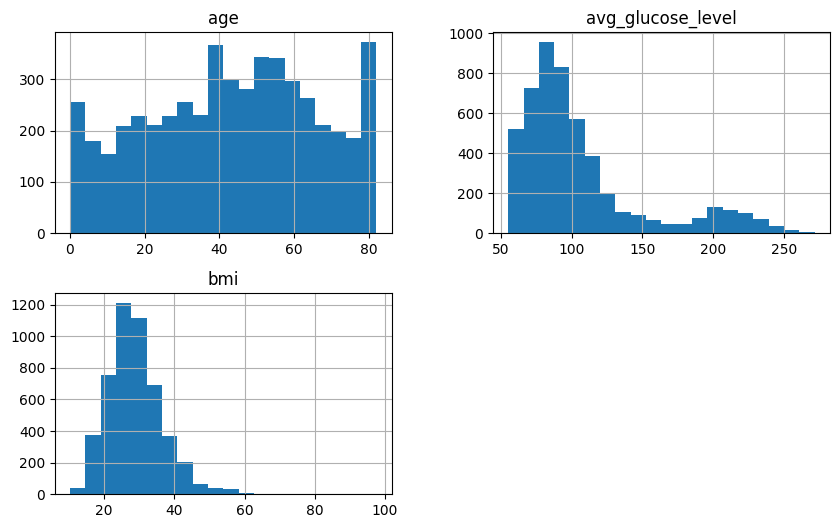

In [ ]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
df[num_cols].hist(figsize=(10, 6), bins=20)
plt.show()

## 9. Distribuição das variáveis numéricas

As distribuições das variáveis numéricas foram analisadas para entender padrões, assimetrias e possíveis outliers.

Observa-se que variáveis como `avg_glucose_level` apresentam assimetria, enquanto `bmi` possui distribuição mais concentrada.

Variáveis binárias foram desconsideradas nesta análise por não agregarem informação relevante nesse tipo de visualização.

In [ ]:
for col in cat_cols:
    print(f"\nRelação entre {col} e stroke:")
    display(pd.crosstab(df[col], df['stroke'], normalize='index') * 100)


Relação entre gender e stroke:


stroke,0,1
gender,,
Female,95.290581,4.709419
Male,94.893617,5.106383
Other,100.000000,0.000000



Relação entre ever_married e stroke:


stroke,0,1
ever_married,,
No,98.349459,1.650541
Yes,93.438712,6.561288



Relação entre work_type e stroke:


stroke,0,1
work_type,,
Govt_job,94.977169,5.022831
Never_worked,100.000000,0.000000
Private,94.905983,5.094017
Self-employed,92.063492,7.936508
children,99.708879,0.291121



Relação entre Residence_type e stroke:


stroke,0,1
Residence_type,,
Rural,95.465394,4.534606
Urban,94.799692,5.200308



Relação entre smoking_status e stroke:


stroke,0,1
smoking_status,,
Unknown,96.955959,3.044041
formerly smoked,92.090395,7.909605
never smoked,95.243129,4.756871
smokes,94.676806,5.323194


## 10. Relação entre variáveis categóricas e ocorrência de AVC

A análise das variáveis categóricas evidenciou que algumas apresentam maior diferenciação em relação ao target.

Destacam-se:
- `ever_married`, com maior proporção de AVC entre indivíduos casados
- `work_type`, especialmente na categoria "Self-employed"
- `smoking_status`, com maior incidência entre indivíduos que já fumaram

Por outro lado, variáveis como `gender` e `Residence_type` apresentaram pouca variação entre as classes, indicando menor poder discriminativo.

Esses resultados auxiliam na compreensão do comportamento dos dados e na avaliação da relevância das variáveis para o modelo.

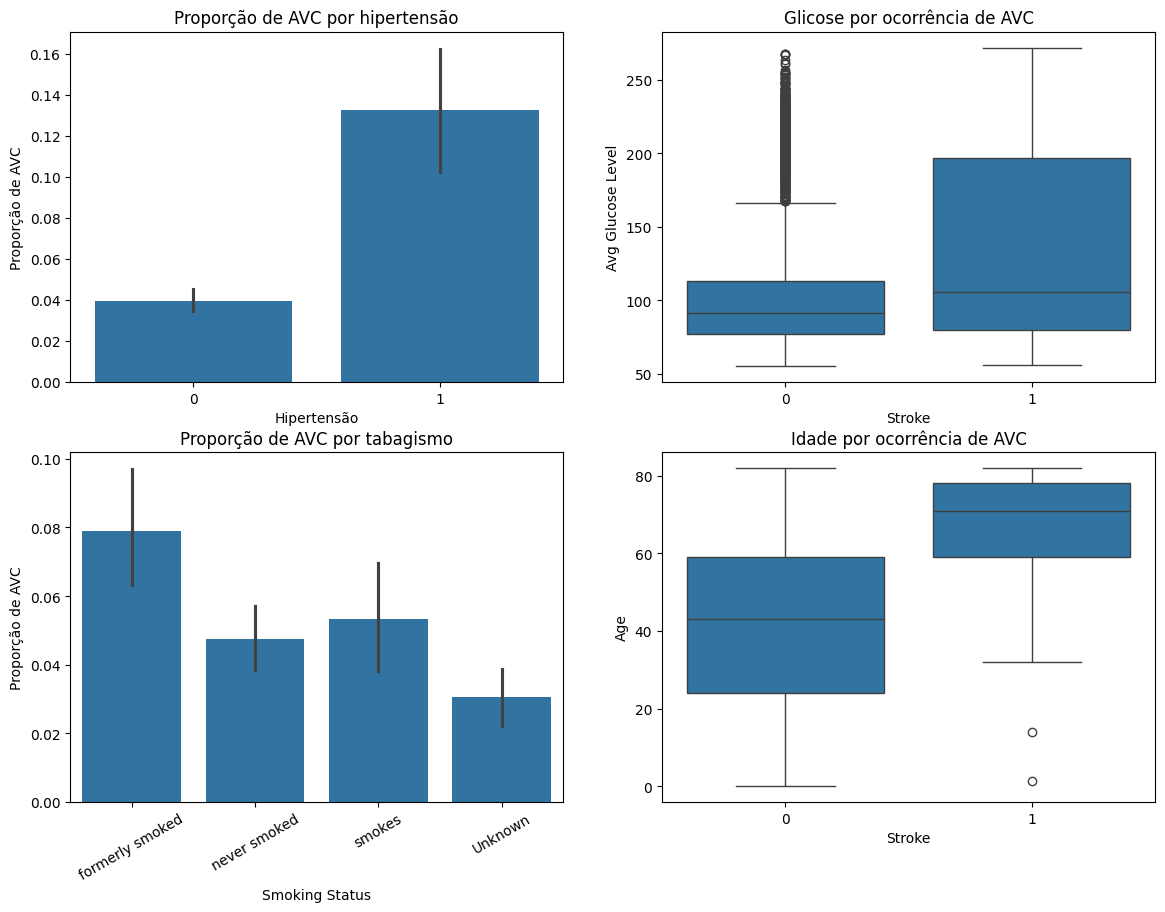

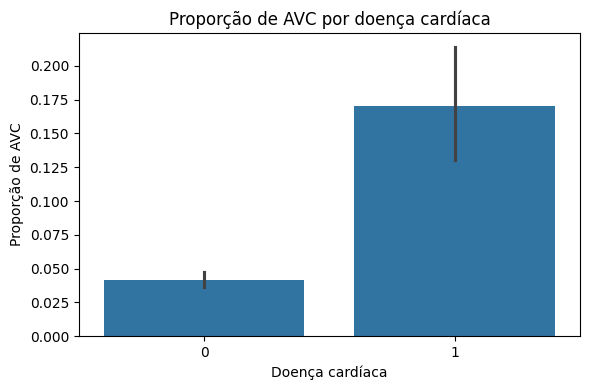

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

# 1. Hipertensão vs Stroke
plt.subplot(2, 2, 1)
sns.barplot(data=df, x='hypertension', y='stroke')
plt.title('Proporção de AVC por hipertensão')
plt.xlabel('Hipertensão')
plt.ylabel('Proporção de AVC')

# 2. Glicose vs Stroke
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='stroke', y='avg_glucose_level')
plt.title('Glicose por ocorrência de AVC')
plt.xlabel('Stroke')
plt.ylabel('Avg Glucose Level')

# 3. Tabagismo vs Stroke
plt.subplot(2, 2, 3)
sns.barplot(data=df, x='smoking_status', y='stroke')
plt.xticks(rotation=30)
plt.title('Proporção de AVC por tabagismo')
plt.xlabel('Smoking Status')
plt.ylabel('Proporção de AVC')

# 4. Idade vs Stroke (substituindo BMI)
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='stroke', y='age')
plt.title('Idade por ocorrência de AVC')
plt.xlabel('Stroke')
plt.ylabel('Age')

# 5. Doença Cardiaca vs Stroke
plt.figure(figsize=(6,4))

sns.barplot(data=df, x='heart_disease', y='stroke')
plt.title('Proporção de AVC por doença cardíaca')
plt.xlabel('Doença cardíaca')
plt.ylabel('Proporção de AVC')

plt.tight_layout()
plt.show()


## 11. Seleção de fatores de risco

A análise dos fatores de risco evidenciou diferentes níveis de associação com a ocorrência de AVC.

Destacam-se como fatores com forte associação:
- hipertensão
- presença de doença cardíaca
- idade

Além disso, variáveis como nível de glicose e tabagismo também apresentaram associação, embora com menor intensidade.

Esses resultados indicam que a combinação dessas variáveis pode capturar melhor o risco associado ao AVC, justificando a criação de uma variável agregada de fatores de risco.

## 🔧 Pré-processamento

Foram removidas colunas sem valor preditivo e aplicado tratamento de dados ausentes.

As transformações foram realizadas por tipo de variável:

- **Numéricas**: imputação pela mediana e padronização  
- **Categóricas**: imputação pela moda e One-Hot Encoding  

O pré-processamento foi implementado com **ColumnTransformer**, garantindo consistência no pipeline de modelagem.

In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Tuple, List

import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def load_data(file_path: str | Path) -> pd.DataFrame:
    """
    Carrega o dataset a partir de um arquivo CSV.
    """
    return pd.read_csv(file_path)


def drop_unused_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove colunas que não agregam valor preditivo ao modelo.
    Exemplo: 'id'.
    """
    df = df.copy()

    columns_to_drop = [col for col in ["id"] if col in df.columns]
    return df.drop(columns=columns_to_drop)


def split_features_target(
    df: pd.DataFrame,
    target_column: str = "stroke",
) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separa variáveis preditoras (X) e variável alvo (y).
    """
    if target_column not in df.columns:
        raise ValueError(f"A coluna alvo '{target_column}' não existe no DataFrame.")

    X = df.drop(columns=[target_column])
    y = df[target_column]

    return X, y


def get_feature_types(X: pd.DataFrame) -> Tuple[List[str], List[str]]:
    """
    Identifica colunas numéricas e categóricas.
    """
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

    return numeric_features, categorical_features


def build_preprocessor(
    numeric_features: List[str],
    categorical_features: List[str],
) -> ColumnTransformer:
    """
    Cria o pipeline de pré-processamento:
    - Numéricas: imputação pela mediana + padronização
    - Categóricas: imputação pela moda + one-hot encoding
    """

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    return preprocessor

## 🤖 Modelagem

Nesta etapa, foram avaliados dois modelos de classificação: **Logistic Regression** e **Gradient Boosting**.

Ambos foram treinados utilizando o mesmo pipeline de pré-processamento e balanceamento com SMOTE, garantindo uma comparação justa entre as abordagens.

A avaliação dos modelos foi realizada com base nas métricas **recall**, **precision** e **ROC AUC**, com foco principal na capacidade de detectar casos positivos (AVC). Embora o F1-score tenha sido calculado como métrica complementar, ele não foi utilizado como critério principal de decisão, pois o problema exige priorização da métrica de recall.

Além disso, foi aplicado um **ajuste de threshold**, com o objetivo de garantir um **recall mínimo de 0.7**, priorizando a redução de falsos negativos e melhorando a adequação do modelo ao contexto do problema.

In [1]:
# =========================
# TESTE LOGISTIC REGRESSION
# =========================

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


# 1. Separar features e target
X, y = split_features_target(df)

# 2. Split treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 3. Identificar tipos de variáveis
numeric_features, categorical_features = get_feature_types(X_train)

# 4. Criar preprocessor usando sua função
preprocessor_lr = build_preprocessor(
    numeric_features,
    categorical_features
)

# 5. Pipeline Logistic Regression
lr_pipeline = ImbPipeline(steps=[
    ("preprocessing", preprocessor_lr),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    )),
])

# 6. Treino
lr_pipeline.fit(X_train, y_train)

# 7. Probabilidades
y_probs_lr = lr_pipeline.predict_proba(X_test)[:, 1]


# =========================
# AVALIAÇÃO - THRESHOLD PADRÃO
# =========================

y_pred_lr_default = (y_probs_lr >= 0.5).astype(int)

print("=== Logistic Regression | Threshold padrão (0.5) ===")
print(classification_report(y_test, y_pred_lr_default))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_default))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_probs_lr))


# =========================
# AJUSTE DE THRESHOLD (recall >= 0.7)
# =========================

desired_recall = 0.7

precision, recall, thresholds = precision_recall_curve(y_test, y_probs_lr)

valid_idxs = np.where(recall[:-1] >= desired_recall)[0]

print("\n=== Ajuste de Threshold (recall >= 0.7) ===")

if len(valid_idxs) > 0:
    best_idx = valid_idxs[np.argmax(precision[valid_idxs])]
    best_threshold = thresholds[best_idx]

    print(f"Melhor threshold: {best_threshold:.4f}")
    print(f"Precision: {precision[best_idx]:.4f}")
    print(f"Recall: {recall[best_idx]:.4f}")

    y_pred_lr_adjusted = (y_probs_lr >= best_threshold).astype(int)

    print("\n=== Logistic Regression | Threshold ajustado ===")
    print(classification_report(y_test, y_pred_lr_adjusted))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_lr_adjusted))

else:
    print("Nenhum threshold atingiu o recall desejado.")

NameError: name 'split_features_target' is not defined

In [ ]:
# =========================
# TESTE GRADIENT BOOSTING
# =========================

# 1. Split treino / teste
from sklearn.model_selection import train_test_split

X, y = split_features_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# 2. Tipos de variáveis
numeric_features, categorical_features = get_feature_types(X_train)

# 3. Preprocessor
preprocessor_gb = build_preprocessor(
    numeric_features,
    categorical_features
)

# 4. Pipeline Gradient Boosting
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = ImbPipeline(steps=[
    ("preprocessing", preprocessor_gb),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )),
])

# 5. Treino
gb_pipeline.fit(X_train, y_train)

# 6. Probabilidades
y_probs_gb = gb_pipeline.predict_proba(X_test)[:, 1]

# =========================
# AVALIAÇÃO - THRESHOLD PADRÃO
# =========================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_gb_default = (y_probs_gb >= 0.5).astype(int)

print("=== Gradient Boosting | Threshold padrão (0.5) ===")
print(classification_report(y_test, y_pred_gb_default))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb_default))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_probs_gb))


# =========================
# AJUSTE DE THRESHOLD (recall >= 0.7)
# =========================
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_probs_gb)

results = []

for p, r, t in zip(precision[:-1], recall[:-1], thresholds):
    if r >= 0.7:
        results.append((t, p, r))

print("\n=== Ajuste de Threshold (recall >= 0.7) ===")

if results:
    best_threshold, best_precision, best_recall = max(results, key=lambda x: x[1])

    print(f"Melhor threshold: {best_threshold:.4f}")
    print(f"Precision: {best_precision:.4f}")
    print(f"Recall: {best_recall:.4f}")

    # Aplicar threshold ajustado
    y_pred_gb_adjusted = (y_probs_gb >= best_threshold).astype(int)

    print("\n=== Gradient Boosting | Threshold ajustado ===")
    print(classification_report(y_test, y_pred_gb_adjusted))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred_gb_adjusted))

else:
    print("Nenhum threshold atingiu recall >= 0.7")

=== Gradient Boosting | Threshold padrão (0.5) ===
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       972
           1       0.19      0.42      0.26        50

    accuracy                           0.89      1022
   macro avg       0.58      0.66      0.60      1022
weighted avg       0.93      0.89      0.90      1022


Confusion Matrix:
[[884  88]
 [ 29  21]]

ROC AUC:
0.8018518518518518

=== Ajuste de Threshold (recall >= 0.7) ===
Melhor threshold: 0.2622
Precision: 0.1228
Recall: 0.7000

=== Gradient Boosting | Threshold ajustado ===
              precision    recall  f1-score   support

           0       0.98      0.74      0.84       972
           1       0.12      0.70      0.21        50

    accuracy                           0.74      1022
   macro avg       0.55      0.72      0.53      1022
weighted avg       0.94      0.74      0.81      1022


Confusion Matrix:
[[722 250]
 [ 15  35]]
